In [11]:

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/uganda_fake_news_v2_cleaned.csv")
df.head()


,id,text,label,source,platform_type,language,date_collected,text_length
0,UG_TRUE_201,Ekitike's Quickfire Brace Flips Liverpool's Cl...,True,BBC News,traditional_media,English,1/31/2026,8
1,UG_TRUE_202,Ronaldo Hits 961st Goal in Al Nassr's 3-0 Rout...,True,BBC News,traditional_media,English,1/31/2026,12
2,UG_TRUE_203,Minister Muyingo’s Seeta Junior gets 56 fours ...,True,Daily Monitor,traditional_media,English,2/2/2026,15
3,UG_TRUE_204,"High Prices, Low Turnout Mark Back-to-School R...",True,Nile Post,traditional_media,English,2/9/2026,9
4,UG_TRUE_205,Auditor General Slams Pornography Control Comm...,True,Nile Post,traditional_media,English,2/9/2026,10


In [12]:


print(df.columns)
print(df.shape)

Index(['id', 'text', 'label', 'source', 'platform_type', 'language',
       'date_collected', 'text_length'],
      dtype='object')
(1482, 8)


In [13]:
df.duplicated(subset=["text"]).sum()

np.int64(0)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1482 entries, 0 to 1481
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              1482 non-null   object
 1   text            1482 non-null   object
 2   label           1482 non-null   bool  
 3   source          1482 non-null   object
 4   platform_type   1482 non-null   object
 5   language        1482 non-null   object
 6   date_collected  1482 non-null   object
 7   text_length     1482 non-null   int64 
dtypes: bool(1), int64(1), object(6)
memory usage: 82.6+ KB


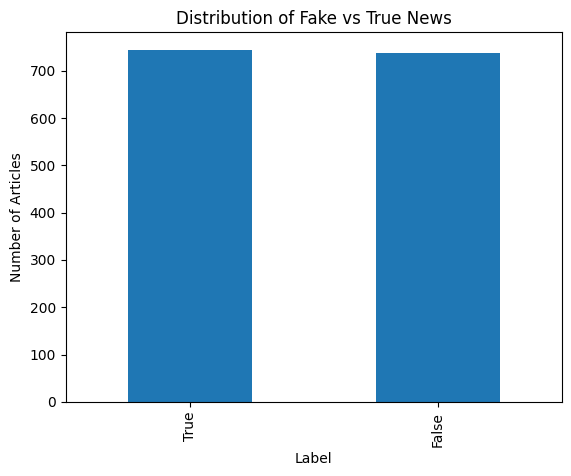

In [15]:
# Visualize the distribution of fake vs true news articles
label_counts = df['label'].value_counts()

label_counts.plot(kind='bar')
plt.title("Distribution of Fake vs True News")
plt.xlabel("Label")
plt.ylabel("Number of Articles")
plt.show()

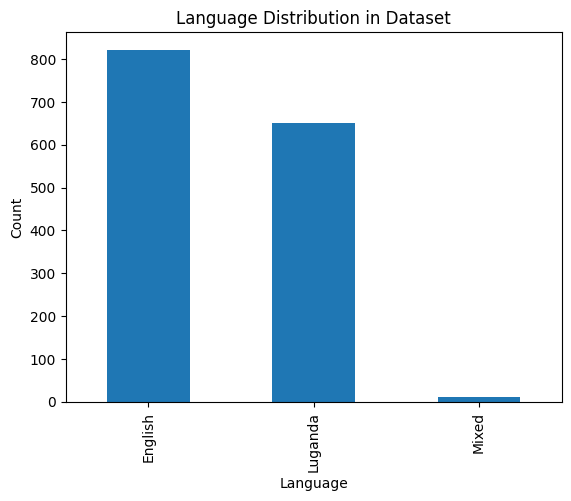

In [16]:
# Visualize the distribution of languages in the dataset
df['language'].value_counts().plot(kind='bar')
plt.title("Language Distribution in Dataset")
plt.xlabel("Language")
plt.ylabel("Count")
plt.show()

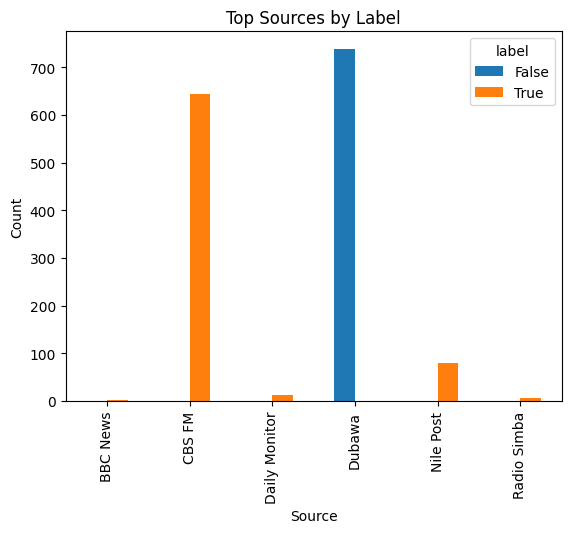

In [17]:
# Cross-tabulation of source and label
pd.crosstab(df['source'], df['label']).head(10)

# Visualize the top sources by label
top_sources = df['source'].value_counts().head(10).index
pd.crosstab(df[df['source'].isin(top_sources)]['source'], df['label']).plot(kind='bar')
plt.title("Top Sources by Label")
plt.xlabel("Source")
plt.ylabel("Count")
plt.show()


In [18]:


# Generate word clouds for fake and true news articles
fake_text = " ".join(df[df['label'] == 'FAKE']['text'])
true_text = " ".join(df[df['label'] == 'TRUE']['text'])

# Word frequency analysis for fake news
from collections import Counter

Counter(fake_text.lower().split()).most_common(10)

[]

In [19]:
# Word frequency analysis for true news
Counter(true_text.lower().split()).most_common(10)

[]

In [20]:

# Descriptive statistics for key columns
df[['label','text_length','language','source']].describe(include='all')

,label,text_length,language,source
count,1482,1482.000000,1482,1482
unique,2,NaN,3,6
top,True,NaN,English,Dubawa
freq,744,NaN,822,738
mean,NaN,12.153846,NaN,NaN
std,NaN,3.848667,NaN,NaN
min,NaN,4.000000,NaN,NaN
25%,NaN,9.000000,NaN,NaN
50%,NaN,12.000000,NaN,NaN
75%,NaN,14.000000,NaN,NaN
